Nombre de slices : 70
Epoch 1, Loss: 1.1974, Dice: 0.5457
Epoch 2, Loss: 0.9790, Dice: 0.7961
Epoch 3, Loss: 0.8398, Dice: 0.8423
Epoch 4, Loss: 0.6926, Dice: 0.8649
Epoch 5, Loss: 0.5572, Dice: 0.8772
Epoch 6, Loss: 0.4135, Dice: 0.9098
Epoch 7, Loss: 0.3204, Dice: 0.8987
Epoch 8, Loss: 0.2542, Dice: 0.9022
Epoch 9, Loss: 0.1818, Dice: 0.9299
Epoch 10, Loss: 0.2031, Dice: 0.8907
Epoch 11, Loss: 0.1493, Dice: 0.9241
Epoch 12, Loss: 0.1310, Dice: 0.9283
Epoch 13, Loss: 0.1083, Dice: 0.9406
Epoch 14, Loss: 0.1089, Dice: 0.9347
Epoch 15, Loss: 0.1092, Dice: 0.9316
Epoch 16, Loss: 0.1012, Dice: 0.9360
Epoch 17, Loss: 0.0919, Dice: 0.9412
Epoch 18, Loss: 0.0867, Dice: 0.9437
Epoch 19, Loss: 0.0773, Dice: 0.9494
Epoch 20, Loss: 0.1186, Dice: 0.9134
Epoch 21, Loss: 0.0964, Dice: 0.9313
Epoch 22, Loss: 0.0757, Dice: 0.9478
Epoch 23, Loss: 0.0734, Dice: 0.9492
Epoch 24, Loss: 0.0724, Dice: 0.9483
Epoch 25, Loss: 0.0643, Dice: 0.9548
Epoch 26, Loss: 0.0682, Dice: 0.9512
Epoch 27, Loss: 0.0685, D

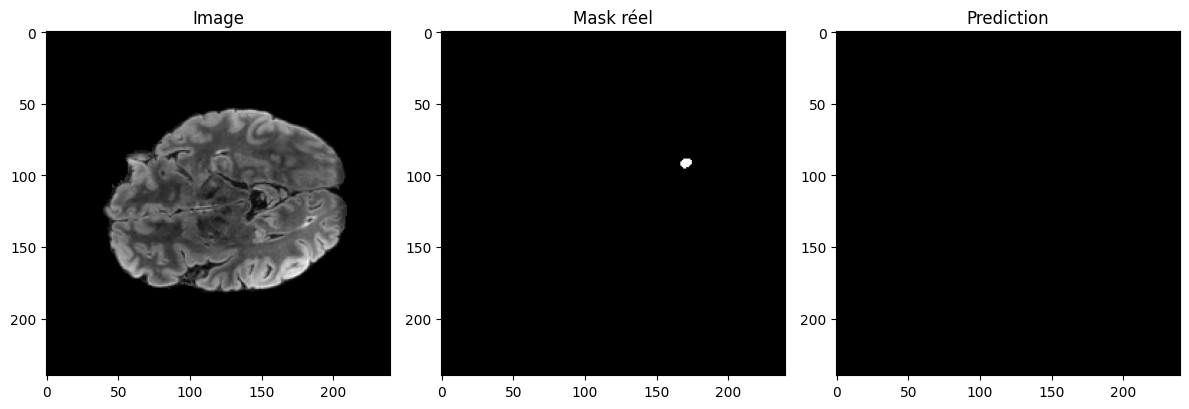

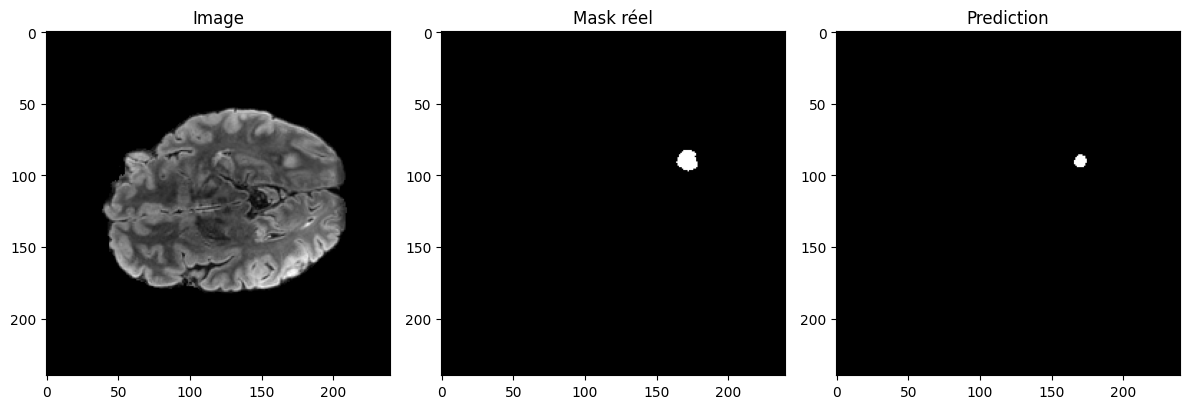

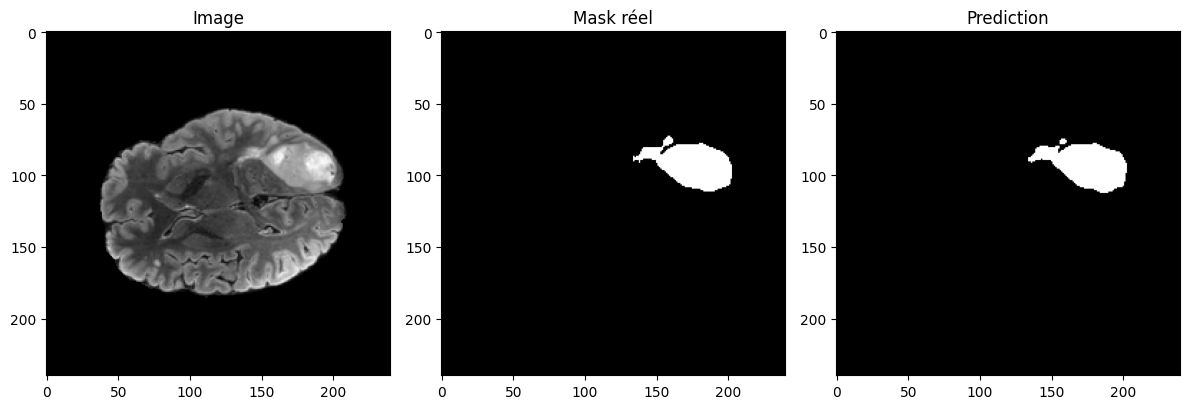

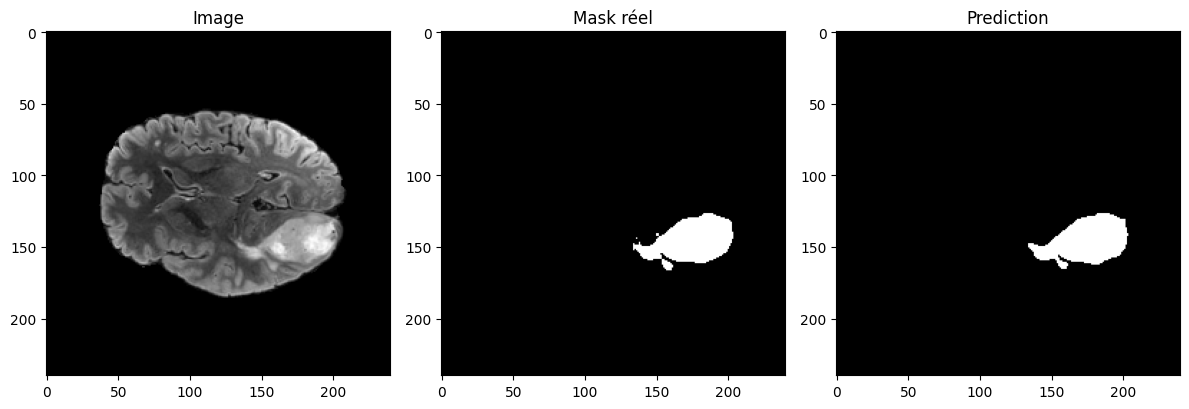

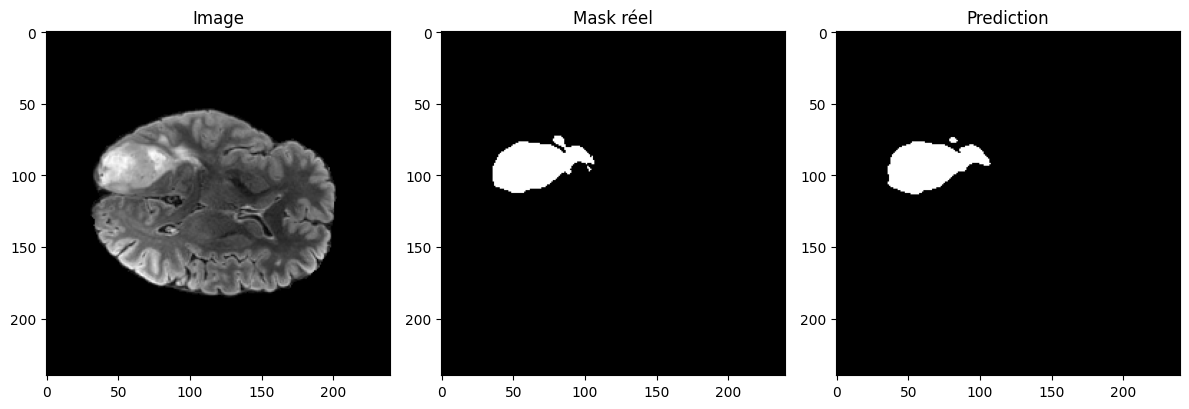

In [ ]:
# import os
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import numpy as np
# from PIL import Image
# import nibabel as nib
# import matplotlib.pyplot as plt


# DATA_PATH = "data/raw/BraTS2021_00001/BraTS2021_00495/"
# output_img_dir = "data/images"
# output_mask_dir = "data/masks"

# os.makedirs(output_img_dir, exist_ok=True)
# os.makedirs(output_mask_dir, exist_ok=True)

# def load_nifti(path):
#     return nib.load(path).get_fdata()

# def normalize(image):
#     std = np.std(image)
#     if std == 0:
#         return image
#     return (image - np.mean(image)) / std

# def extract_slices(volume, mask):
#     images = []
#     masks = []

#     for i in range(volume.shape[2]):
#         img_slice = volume[:, :, i]
#         mask_slice = mask[:, :, i]

#         if np.sum(mask_slice) > 0:
#             img_slice = normalize(img_slice)
#             mask_slice = (mask_slice > 0).astype(np.float32)

#             images.append(img_slice)
#             masks.append(mask_slice)

#     images = np.array(images)
#     masks = np.array(masks)

#     # Ajouter dimension channel
#     images = images[:, np.newaxis, :, :]
#     masks = masks[:, np.newaxis, :, :]

#     return images, masks

# # Charger volumes
# image_path = os.path.join(DATA_PATH, "BraTS2021_00495_flair.nii.gz")
# mask_path = os.path.join(DATA_PATH, "BraTS2021_00495_seg.nii.gz")

# volume = load_nifti(image_path)
# mask = load_nifti(mask_path)

# images, masks = extract_slices(volume, mask)
# print("Nombre de slices extraites :", len(images))

# # Sauvegarde PNG pour le Dataset
# for i in range(len(images)):
#     img = (images[i][0] * 255).astype(np.uint8)
#     msk = (masks[i][0] * 255).astype(np.uint8)

#     Image.fromarray(img).save(f"{output_img_dir}/img_{i}.png")
#     Image.fromarray(msk).save(f"{output_mask_dir}/mask_{i}.png")

# print("Prétraitement terminé : images et masques sauvegardés en PNG.")

# # -------------------------
# # 2. Dataset PyTorch
# # -------------------------
# class SegmentationDataset(Dataset):
#     def __init__(self, images_dir, masks_dir, transform=None):
#         self.image_paths = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(".png")])
#         self.mask_paths = sorted([os.path.join(masks_dir, f) for f in os.listdir(masks_dir) if f.endswith(".png")])
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         image = np.array(Image.open(self.image_paths[idx]).convert("L"), dtype=np.float32) / 255.0
#         mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32) / 255.0
#         image = torch.from_numpy(image).unsqueeze(0)  # Channel dimension
#         mask = torch.from_numpy(mask).unsqueeze(0)
#         return image, mask

# # -------------------------
# # 3. UNet Model
# # -------------------------
# class UNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.enc1 = self.conv_block(1, 64)
#         self.pool = nn.MaxPool2d(2)
#         self.bottleneck = self.conv_block(64, 128)
#         self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
#         self.dec1 = self.conv_block(128, 64)
#         self.final = nn.Conv2d(64, 1, 1)

#     def conv_block(self, in_ch, out_ch):
#         return nn.Sequential(
#             nn.Conv2d(in_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         x1 = self.enc1(x)
#         x2 = self.pool(x1)
#         x3 = self.bottleneck(x2)
#         up = self.up1(x3)
#         cat = torch.cat([up, x1], dim=1)
#         out = self.dec1(cat)
#         return torch.sigmoid(self.final(out))

# # -------------------------
# # 4. Dice Loss
# # -------------------------
# def dice_loss(pred, target, smooth=1e-6):
#     pred = pred.view(-1)
#     target = target.view(-1)
#     intersection = (pred * target).sum()
#     dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
#     return 1 - dice

# # -------------------------
# # 5. Training Setup
# # -------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# dataset = SegmentationDataset(output_img_dir, output_mask_dir)
# print("Nombre d'exemples dans le dataset :", len(dataset))

# dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# model = UNet().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # -------------------------
# # 6. Training Loop
# # -------------------------
# num_epochs = 10
# for epoch in range(num_epochs):
#     model.train()
#     epoch_loss = 0
#     for img, mask in dataloader:
#         img = img.to(device).float()
#         mask = mask.to(device).float()

#         pred = model(img)
#         loss = dice_loss(pred, mask)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
    
#     print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(dataloader):.4f}")

# # Sauvegarder le modèle
# torch.save(model.state_dict(), "model.pth")
# print("Modèle sauvegardé dans model.pth")

# # -------------------------
# # 7. Visualisation
# # -------------------------
# def show(image, mask, pred):
#     image = image.squeeze()
#     mask = mask.squeeze()
#     pred = pred.squeeze()

#     plt.figure(figsize=(12,4))
#     plt.subplot(1,3,1)
#     plt.title("Image")
#     plt.imshow(image, cmap='gray')

#     plt.subplot(1,3,2)
#     plt.title("Mask (Vérité)")
#     plt.imshow(mask, cmap='gray')

#     plt.subplot(1,3,3)
#     plt.title("Prediction")
#     plt.imshow(pred > 0.5, cmap='gray')

#     plt.tight_layout()
#     plt.show()

# # Tester sur quelques images
# model.eval()
# for i in range(min(3, len(dataset))):
#     img, mask = dataset[i]
#     img_tensor = img.unsqueeze(0).to(device).float()
#     with torch.no_grad():
#         pred = model(img_tensor)
#     show(img, mask, pred.cpu())





import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import nibabel as nib
import matplotlib.pyplot as plt
import random

# -------------------------
# 1. Prétraitement
# -------------------------
DATA_PATH = "data/raw/BraTS2021_00001/BraTS2021_00495/"
output_img_dir = "data/images"
output_mask_dir = "data/masks"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

def load_nifti(path):
    return nib.load(path).get_fdata()

def normalize(image):
    std = np.std(image)
    if std == 0:
        return image
    return (image - np.mean(image)) / std

def extract_slices(volume, mask):
    images, masks = [], []

    for i in range(volume.shape[2]):
        img_slice = volume[:, :, i]
        mask_slice = mask[:, :, i]

        if np.sum(mask_slice) > 0:
            img_slice = normalize(img_slice)
            mask_slice = (mask_slice > 0).astype(np.float32)

            images.append(img_slice)
            masks.append(mask_slice)

    images = np.array(images)
    masks = np.array(masks)

    images = images[:, np.newaxis, :, :]
    masks = masks[:, np.newaxis, :, :]

    return images, masks

# Charger données
image_path = os.path.join(DATA_PATH, "BraTS2021_00495_flair.nii.gz")
mask_path = os.path.join(DATA_PATH, "BraTS2021_00495_seg.nii.gz")

volume = load_nifti(image_path)
mask = load_nifti(mask_path)

images, masks = extract_slices(volume, mask)
print("Nombre de slices :", len(images))

# Sauvegarde PNG (normalisation améliorée)
for i in range(len(images)):
    img = images[i][0]
    img = ((img - img.min()) / (img.max() - img.min() + 1e-6) * 255).astype(np.uint8)
    msk = (masks[i][0] * 255).astype(np.uint8)

    Image.fromarray(img).save(f"{output_img_dir}/img_{i}.png")
    Image.fromarray(msk).save(f"{output_mask_dir}/mask_{i}.png")

# -------------------------
# 2. Dataset + Augmentation
# -------------------------
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.image_paths = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(".png")])
        self.mask_paths = sorted([os.path.join(masks_dir, f) for f in os.listdir(masks_dir) if f.endswith(".png")])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("L"), dtype=np.float32) / 255.0
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32) / 255.0

        # Data augmentation
        if random.random() > 0.5:
            image = np.fliplr(image)
            mask = np.fliplr(mask)

        if random.random() > 0.5:
            image = np.flipud(image)
            mask = np.flipud(mask)

        image = torch.from_numpy(image.copy()).unsqueeze(0)
        mask = torch.from_numpy(mask.copy()).unsqueeze(0)

        return image, mask

# -------------------------
# 3. UNet amélioré
# -------------------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = self.conv_block(1, 64)
        self.enc2 = self.conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = self.conv_block(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))

        x3 = self.bottleneck(self.pool(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return torch.sigmoid(self.final(x))

# -------------------------
# 4. Loss + métrique
# -------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice

def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

# -------------------------
# 5. Training Setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = SegmentationDataset(output_img_dir, output_mask_dir)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
bce = nn.BCELoss()

# -------------------------
# 6. Training Loop
# -------------------------
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_dice = 0

    for img, mask in dataloader:
        img = img.to(device).float()
        mask = mask.to(device).float()

        pred = model(img)

        loss = dice_loss(pred, mask) + bce(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_dice += dice_score(pred, mask).item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(dataloader):.4f}, Dice: {epoch_dice/len(dataloader):.4f}")

# Sauvegarde
torch.save(model.state_dict(), "model.pth")

# -------------------------
# 7. Visualisation
# -------------------------
def show(image, mask, pred):
    image = image.squeeze()
    mask = mask.squeeze()
    pred = pred.squeeze()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image, cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Mask réel")
    plt.imshow(mask, cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred > 0.5, cmap='gray')

    plt.tight_layout()
    plt.show()

# Test
model.eval()
for i in range(min(5, len(dataset))):
    img, mask = dataset[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
    show(img, mask, pred.cpu())
    